In [1]:
import sys
sys.path.append('../')
from joblib import Parallel, delayed
import numpy as np
import matplotlib.pyplot as plt
import scqubits as scq
import pytz
import qutip as qt
from datetime import datetime
import pandas as pd
import utils_2Q_gate_zp as ut

In [2]:
truncation=10
EL        = 0.377 # GHz
EJ        = 6.013 # Soft Zero Pi (Gyenis)
EC_phi    = 1.142
EC_theta  = 0.092
E_CJ = 2 * EC_phi
E_C = 2./(1./EC_theta -1./EC_phi)
phi_grid = scq.Grid1d(-6*np.pi, 6*np.pi, 200)
zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=0.,
                        ng=0., flux=0., ncut=60, truncated_dim=truncation)
def get_eval(args, index=300):
    zero_pi.ncut, zero_pi.grid.pt_count = args
    evals = zero_pi.eigenvals(evals_count=index+1)
    evals = evals - evals[0]
    return evals[index]

In [3]:
level_index = 299
ncut_vec = np.arange(10, 100, 5).tolist()
phi_grid_vec = np.arange(20, 320, 5).tolist()
print('size=', len(ncut_vec)*len(phi_grid_vec))
grid1, grid2 = np.meshgrid(ncut_vec, phi_grid_vec)
grid = np.stack([grid1.ravel(), grid2.ravel()], axis=-1)
eval_grid = Parallel(n_jobs=100, verbose=1)(delayed(get_eval)(args, level_index)
                                            for args in grid)
eval_grid = np.reshape(eval_grid, (len(ncut_vec), len(phi_grid_vec)))
eval_error = eval_grid - eval_grid[-1, -1]
xy_1ncut = ncut_vec.index(30), phi_grid_vec.index(100)
xy_2ncut = ncut_vec.index(60), phi_grid_vec.index(200)
xy_3ncut = ncut_vec.index(90), phi_grid_vec.index(300)

size= 1080


[Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.
[Parallel(n_jobs=100)]: Done 250 tasks      | elapsed:  1.1min
[Parallel(n_jobs=100)]: Done 600 tasks      | elapsed:  5.5min
[Parallel(n_jobs=100)]: Done 1080 out of 1080 | elapsed: 17.1min finished


In [4]:
ncut_vec = np.arange(10, 100, 5).tolist()
phi_grid_vec = np.arange(20, 320, 5).tolist()
print(phi_grid_vec)

[20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315]


 /tmp/ipykernel_2219537/4266525989.py: 3

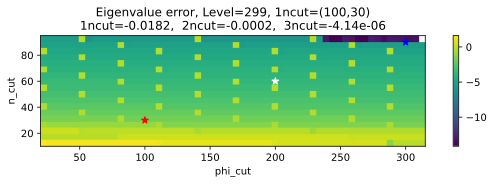

In [5]:
fig, ax = plt.subplots(figsize=(10, 2))
extent = [phi_grid_vec[0], phi_grid_vec[-1], ncut_vec[0], ncut_vec[-1]]
mat = np.log10(np.abs(eval_error))
cbar = ax.imshow(mat, extent=extent, origin='lower', aspect='equal')
plt.scatter(100, 30, color='red', s=50, marker='*', zorder=5)
plt.scatter(200, 60, color='white', s=50, marker='*', zorder=5)
plt.scatter(300, 90, color='blue', s=50, marker='*', zorder=5)

ax.set_title(f'Eigenvalue error, Level={level_index}, 1ncut=(100,30)'
             +f'\n1ncut={eval_error[xy_1ncut]:.3g}'
             +f',  2ncut={eval_error[xy_2ncut]:.3g}'
             +f',  3ncut={eval_error[xy_3ncut]:.3g}'
              )
ax.set_ylabel(r'n_cut' )
ax.set_xlabel(r'phi_cut')
# plt.colorbar()
# colorbar = fig.colorbar(cbar, cax=fig.add_axes([0.76, 0.15, 0.01, 0.7])) # [left, bottom, width, height]
colorbar = fig.colorbar(cbar) # [left, bottom, width, height]

In [6]:
mat[-10:,-10:-4]

array([[ -3.25481741,  -3.25481741,  -3.25481741,  -3.25481741,
         -3.25481741,  -3.25481741],
       [ -3.48360182,  -3.48360182,  -3.48360182,  -3.48360182,
         -0.21730067,  -3.55999997],
       [ -3.76817404,  -3.76817404,  -3.76817404,  -3.76817404,
         -3.76817404,  -3.76817404],
       [ -3.97133584,  -3.97133584,  -3.97133584,  -3.97133584,
         -3.97133584,  -3.97133584],
       [ -4.17050025,  -4.17050025,  -4.17050025,  -4.17050025,
         -0.2157136 ,  -4.2531674 ],
       [ -4.43966524,  -4.43966523,  -4.43966523,  -4.43966523,
         -4.43966524,  -4.43966524],
       [ -4.65580628,  -4.65580628,  -4.65580627,  -4.65580627,
         -4.65580628,  -4.65580627],
       [ -4.90368615,  -4.90368616,  -4.90368616,  -4.90368615,
         -0.21536667,  -5.10376982],
       [ -5.38305179,  -5.3830518 ,  -5.38305181,  -5.3830518 ,
         -5.38305181,  -5.38305181],
       [-14.1484098 , -12.97231854, -13.1484098 , -13.67128854,
        -13.10701711, -13.1

In [7]:
mat[-10:,-10:]

array([[ -3.25481741,  -3.25481741,  -3.25481741,  -3.25481741,
         -3.25481741,  -3.25481741,  -3.25481741,  -3.25481741,
         -3.25481741,  -3.25481741],
       [ -3.48360182,  -3.48360182,  -3.48360182,  -3.48360182,
         -0.21730067,  -3.55999997,  -3.55665112,  -3.55665112,
         -3.55665112,  -3.55665112],
       [ -3.76817404,  -3.76817404,  -3.76817404,  -3.76817404,
         -3.76817404,  -3.76817404,  -3.76817404,  -3.76817404,
         -3.76817404,  -3.76817404],
       [ -3.97133584,  -3.97133584,  -3.97133584,  -3.97133584,
         -3.97133584,  -3.97133584,  -3.97133584,  -3.97133584,
         -3.97133584,  -3.97133584],
       [ -4.17050025,  -4.17050025,  -4.17050025,  -4.17050025,
         -0.2157136 ,  -4.2531674 ,  -4.2368969 ,  -4.2368969 ,
         -4.2368969 ,  -4.2368969 ],
       [ -4.43966524,  -4.43966523,  -4.43966523,  -4.43966523,
         -4.43966524,  -4.43966524,  -4.43966523,  -4.43966524,
         -4.43966523,  -4.43966523],
       [ -

In [8]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
drive_phi, drive_theta, truc = False, True, 30
# drive_phi, drive_theta, truc = True, False, 30
parallel = False
folder = 'data/data_xgate_theta_1ncut.txt' if drive_theta else 'data/data_xgate_phi_1ncut.txt'
f_xgate = pd.read_csv(folder)
params = f_xgate[['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1', 'detune_2']].to_numpy()[:1]
n_cpu, n_job = 4, 4*len(params)
logi_state = [0, 2]
# [H0, drive_term, w_trans_1, w_trans_2, _] = ut.zero_pi_initialize(drive_phi, drive_theta, truncation=truc)
folder = f'data/data_one_zeropi_truncation=1000/'
evals = 2*np.pi* pd.read_csv(folder+ 'evals.txt').to_numpy().flatten()
n_theta = 2*np.pi* pd.read_csv(folder+ 'n_theta.txt').to_numpy()
n_phi = 2*np.pi* pd.read_csv(folder+ 'n_phi.txt').map(complex).to_numpy()
gate_target = qt.sigmax()
gamma2 =  1 / 1600e3
gammas =  1 / 2e3
gamma2_p = 0 / 100e3
# ratio = 10
# gammas =  gamma_2 * ratio
gammas_p = 1 / 9000

jump_t1   = []
jump_tphi = []
gamma_t1   = [0, gammas,  gamma2]  + [gammas]  * (truc-3)
gamma_tphi = [0, gammas_p, gamma2_p] + [gammas_p] * (truc-3)
for i in range(1,truc):
    jump_t1.append( np.sqrt(gamma_t1[i]) * qt.basis(truc,0) * qt.basis(truc,i).dag() )
    jump_tphi.append( np.sqrt(2*gamma_tphi[i]) * qt.basis(truc,i).proj() )

H0 = qt.Qobj(np.diag(evals))
if drive_phi:
    w_trans_1 = evals[9] - evals[0]
    w_trans_2 = evals[9] - evals[2]
    drive_term = n_phi
if drive_theta:
    w_trans_1 = evals[7] - evals[0]
    w_trans_2 = evals[7] - evals[2]
    drive_term = n_theta
hilbert_space = np.arange(truc).tolist()
H0_truc = ut.truncate_2(H0, hilbert_space)
drive_truc = ut.truncate_2(drive_term, hilbert_space)
H_qbt_drive = [H0_truc, [drive_truc, ut.drive_gauss_A],
                        [drive_truc, ut.drive_gauss_B],]


############################################################

c_op_list = [qt.Qobj(np.zeros((truc, truc)))]
args = [H_qbt_drive, w_trans_1, w_trans_2, n_cpu, c_op_list, logi_state, parallel, gate_target]
# f_ideal = [xgate_fidelity_log_noise(params[0], *args)]
f_ideal = Parallel(n_jobs=n_job, verbose=0)(delayed(ut.xgate_fidelity_log_noise)(args_indep, *args)
                                            for args_indep in params)
print('\nf_ideal = [')
for i in range(0, len(f_ideal), 4):
    print(', '.join(map(str, f_ideal[i:i+4])), ',')
print(']')
print("Current Mountain Time:", datetime.now(pytz.timezone('America/Denver')))
############################################################
c_op_list = jump_t1 + jump_tphi
args = [H_qbt_drive, w_trans_1, w_trans_2, n_cpu, c_op_list, logi_state, parallel, gate_target]
f_noise = Parallel(n_jobs=n_job, verbose=0)(delayed(ut.xgate_fidelity_log_noise)(args_indep, *args)
                                            for args_indep in params)
print('\nf_noise = [')
for i in range(0, len(f_noise), 4):
    print(', '.join(map(str, f_noise[i:i+4])), ',')
print(']')